In [ ]:
# Took 20 minutes to fully run on 12th Gen i5-12600KF CPU + Radeon RX 6700 GPU machine with 32GB RAM and 12 GB of VRAM

In [40]:
import numpy as np
import seaborn as sns
import tensorflow as tf
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

import matplotlib.pyplot as plt

# Reproducibility
SEED = 1996
np.random.seed(SEED)
tf.random.set_seed(SEED)

import os

# DATA_DIR = Path("/Users/jessicawentworth/Library/CloudStorage/GoogleDrive-jesstwentworth@gmail.com/My Drive/Machine Learning Group Project") # Google Drive path
DATA_DIR = os.path.join('Pokemon/')

## Define Plots

In [24]:
def plot_training_history(history):
    
    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Model Accuracy")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("Model Loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

In [25]:
def plot_confusion_matrix(model, X_test, y_test, class_names):
    
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(18, 16))

    sns.heatmap(
        cm,
        cmap="Blues",
        cbar=True,
        square=True,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xticks(rotation=90, fontsize=6)   # rotate + shrink
    plt.yticks(rotation=0, fontsize=6)

    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)

    plt.tight_layout(pad=2.0)  
    plt.show()

In [26]:
def generate_classification_report(model, X_test, y_test):
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(classification_report(y_test, y_pred))

In [27]:
def plot_sample_images(X, y, class_names=None, num_images=10):
    
    rng = np.random.default_rng(42)
    indices = rng.choice(len(X), num_images, replace=False)

    plt.figure(figsize=(12, 5))
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        
        img = X[idx].reshape(64, 64, 3)
        plt.imshow(img)
        
        if class_names is not None:
            plt.title(class_names[y[idx]])
        else:
            plt.title(y[idx])
            
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Data Preprocessing
## Load augmentation datasets per version to easily switch datasets

In [34]:
def load_dataset(version="5aug"):
    # base_path = f"Pokemon/{version}/"
    
    # X_train = np.load(base_path + "X_train.npy")
    # y_train = np.load(base_path + "y_train.npy")

    # X_val = np.load(base_path + "X_val.npy")
    # y_val = np.load(base_path + "y_val.npy")

    # X_test = np.load(base_path + "X_test.npy")
    # y_test = np.load(base_path + "y_test.npy")

# JW Alternative
    X_train = np.load(DATA_DIR + f"X_train_{version}.npy")
    y_train = np.load(DATA_DIR + f"y_train_{version}.npy")

    X_val = np.load(DATA_DIR + f"X_val_{version}.npy")
    y_val = np.load(DATA_DIR + f"y_val_{version}.npy")

    X_test = np.load(DATA_DIR + f"X_test_{version}.npy")
    y_test = np.load(DATA_DIR + f"y_test_{version}.npy")

    return X_train, y_train, X_val, y_val, X_test, y_test

The dataset consists of multiple Pokémon classes, extracted from the label array. Each class corresponds to a unique Pokémon category used for classification.
Sample images were reconstructed from flattened arrays back into 64×64×3 format. Visualization confirmed that preprocessing preserved image structure and label integrity.

## Defined Datasets per experiments

In [35]:
def preprocess_data(X_train, X_val, X_test):
    
    # Normalize pixel values to [0, 1]
    X_train = X_train / 255.0
    X_val = X_val / 255.0
    X_test = X_test / 255.0
    
    # FLATTEN images
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_val = X_val.reshape(X_val.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)
    
    return X_train, X_val, X_test

In [36]:
# print("Train shape:", X_train.shape)
# print("Val shape:", X_val.shape)
# print("Test shape:", X_test.shape)

## Build Neural Network

In [37]:
def create_model(input_dim, num_classes):
    
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        
        layers.Dense(512, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),

        layers.Dense(num_classes, activation='softmax')
    ])

#Compile
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# print(X_train.shape)
# model = create_model(X_train.shape[1], len(np.unique(y_train)))
# model.summary()

## Training per Experiment Function

In [38]:
def run_experiment(version):
    
    print(f"\n===== Running {version} Dataset =====")
    
    # Load data
    X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(version)

    # Convert string labels → integers
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_val = le.transform(y_val)
    y_test = le.transform(y_test)

    # Save class names in correct order
    class_names = le.classes_
    
    # Preprocess
    X_train, X_val, X_test = preprocess_data(X_train, X_val, X_test)    
    
    print("Train:", X_train.shape)
    
    # Create model
    model = create_model(X_train.shape[1], len(np.unique(y_train)))
    
    # Train
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=1
    )
    
    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    roc_auc = roc_auc_score(
    y_test,
    y_pred_probs,
    multi_class="ovr",
    average="macro"
)
    
    report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)
    return model, history, acc, X_test, y_test, class_names, report, roc_auc

## Run Experiments


Final Comparison:

===== Running 5aug Dataset =====
Train: (21744, 12288)


/home/viviteto/miniforge3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1776735920.124843   12839 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.0124 - loss: 4.9206 - val_accuracy: 0.0215 - val_loss: 4.6590
Epoch 2/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.0464 - loss: 4.4289 - val_accuracy: 0.0836 - val_loss: 4.0594
Epoch 3/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.0823 - loss: 4.1009 - val_accuracy: 0.1002 - val_loss: 3.8695
Epoch 4/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.1021 - loss: 3.9122 - val_accuracy: 0.1341 - val_loss: 3.7016
Epoch 5/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.1268 - loss: 3.7597 - val_accuracy: 0.1556 - val_loss: 3.5817
Epoch 6/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.1475 - loss: 3.6195 - val_accuracy: 0.1871 - val_loss: 3.4601
Epoch 7/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.1651 - loss: 3.5041 - val_accuracy: 0.1962 - val_loss: 3.3693
Epoch 8/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.1743 - loss: 3.4217 - val_acc

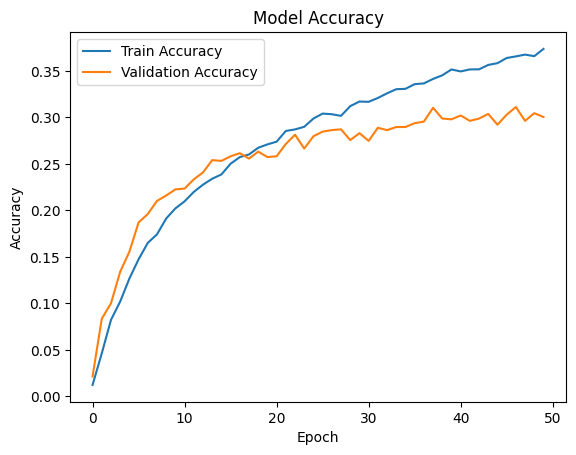

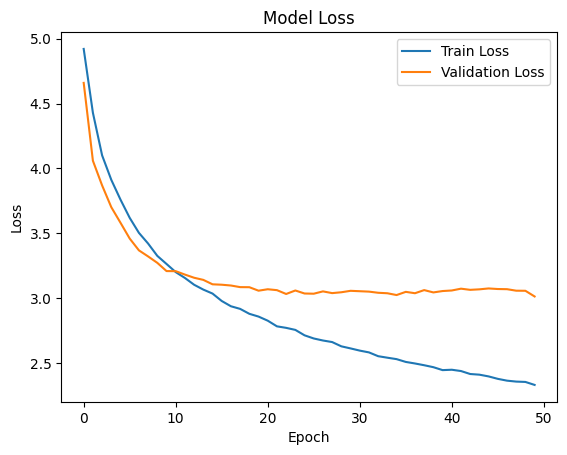

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


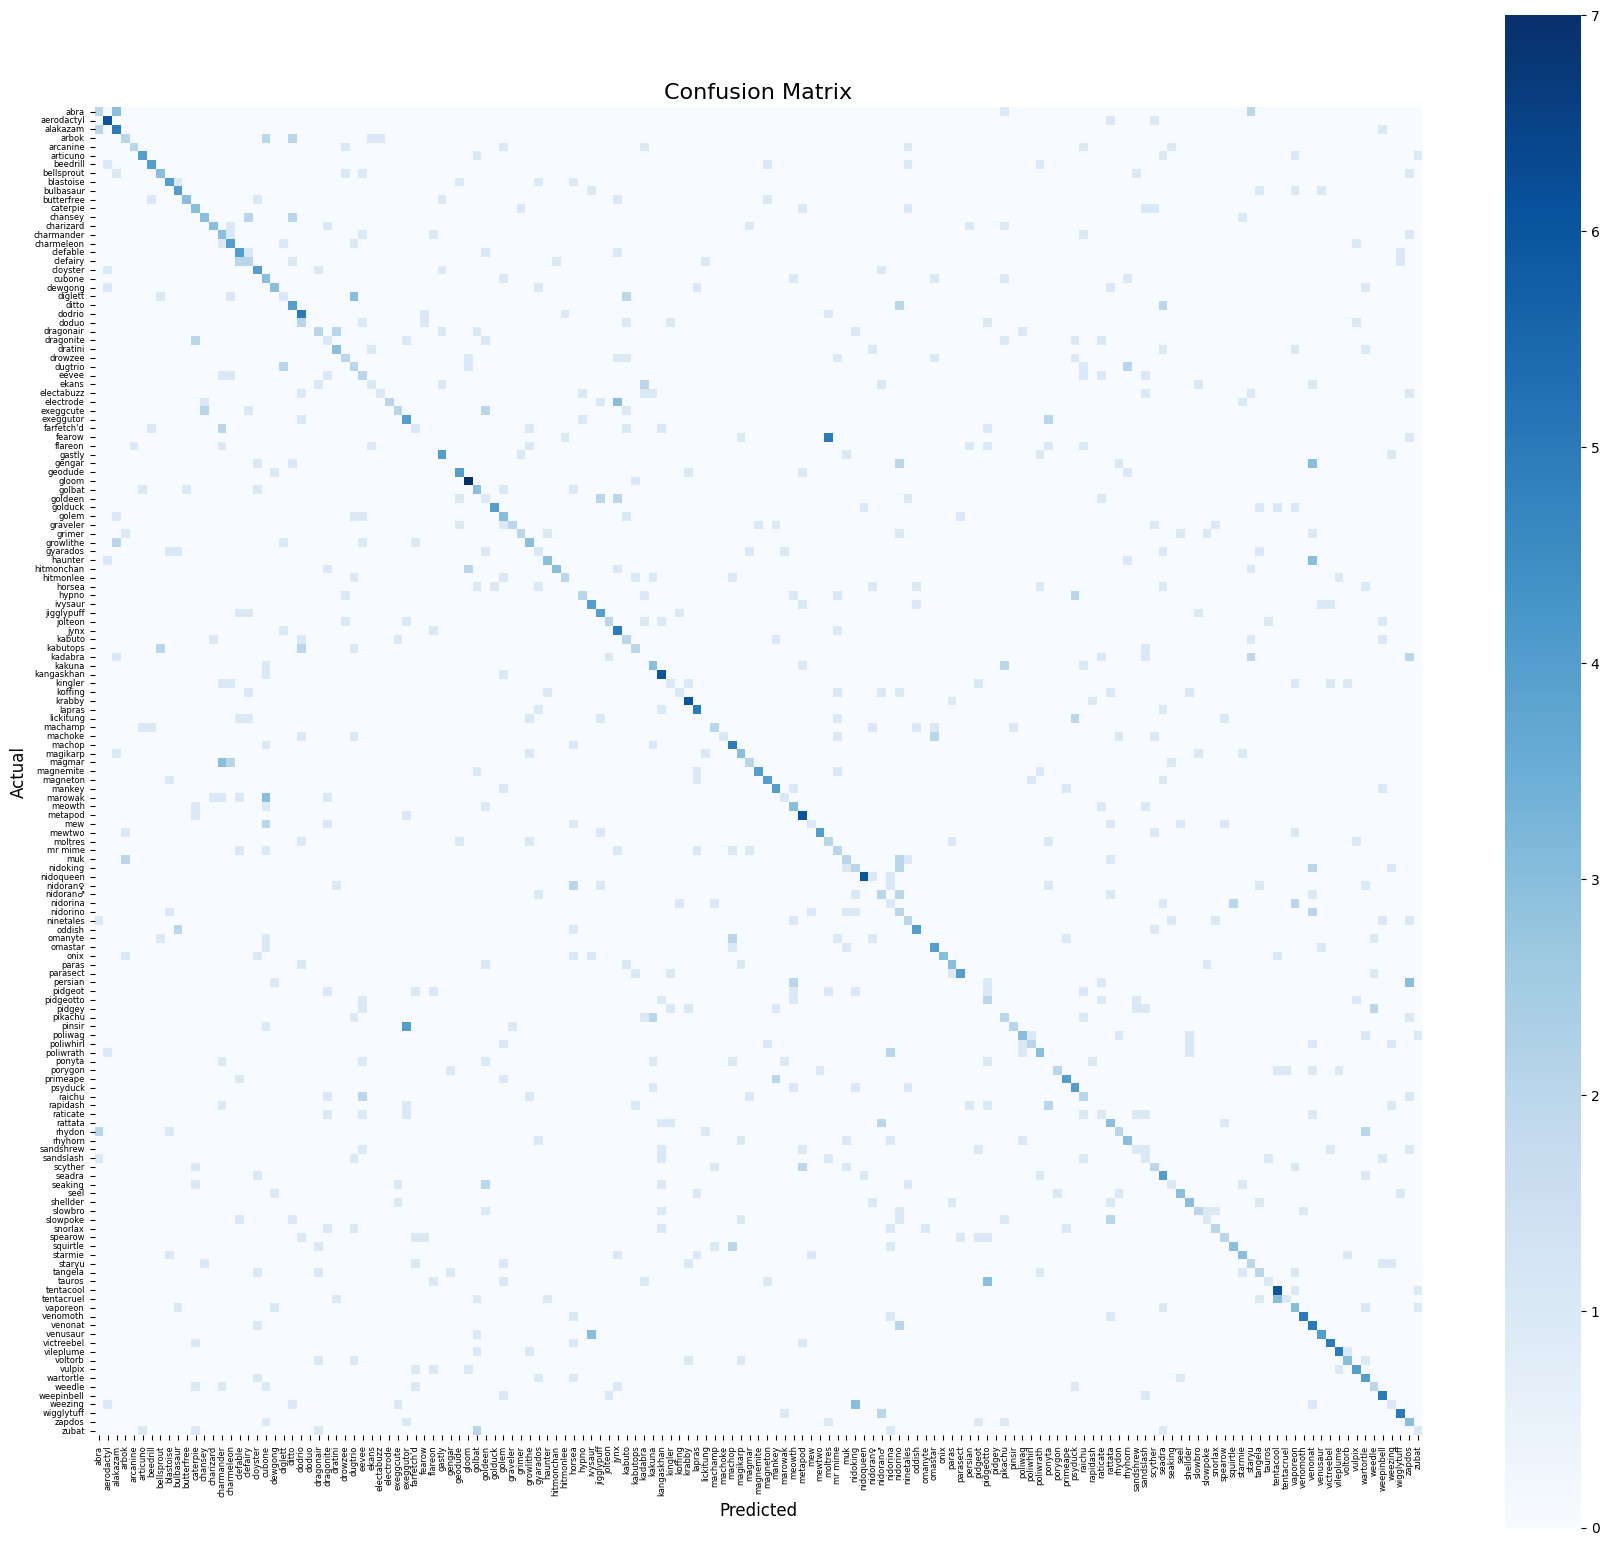

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.25      0.25      0.25         8
           1       0.50      0.75      0.60         8
           2       0.36      0.62      0.45         8
           3       0.29      0.25      0.27         8
           4       0.67      0.25      0.36         8
           5       0.57      0.50      0.53         8
           6       0.57      0.50      0.53         8
           7       0.43      0.38      0.40         8
           8       0.44      0.50      0.47         8
           9       0.44      0.50      0.47         8
          10       0.75      0.38      0.50         8
          11       0.25      0.38      0.30         8
          12       0.43      0.38      0.40         8
          13       0.60      0.38      0.46         8
          14       0.19      0.38      0.25         8
          15       0.36      0.50      0.42         8
          16       0.33      0.50      0.4

/home/viviteto/miniforge3/envs/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/miniforge3/envs/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/miniforge3/envs/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

Train: (39864, 12288)


/home/viviteto/miniforge3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.0173 - loss: 4.8009 - val_accuracy: 0.0439 - val_loss: 4.2909
Epoch 2/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.0412 - loss: 4.3722 - val_accuracy: 0.0853 - val_loss: 4.0143
Epoch 3/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.0668 - loss: 4.1434 - val_accuracy: 0.1250 - val_loss: 3.7287
Epoch 4/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.0897 - loss: 3.9585 - val_accuracy: 0.1449 - val_loss: 3.5765
Epoch 5/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.1055 - loss: 3.8370 - val_accuracy: 0.1623 - val_loss: 3.4853
Epoch 6/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.1166 - loss: 3.7521 - val_accuracy: 0.1747 - val_loss: 3.3949
Epoch 7/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.1282 - loss: 3.6821 - val_accuracy: 0.1887 - val_loss: 3.3360
Epoch 8/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.1347 -

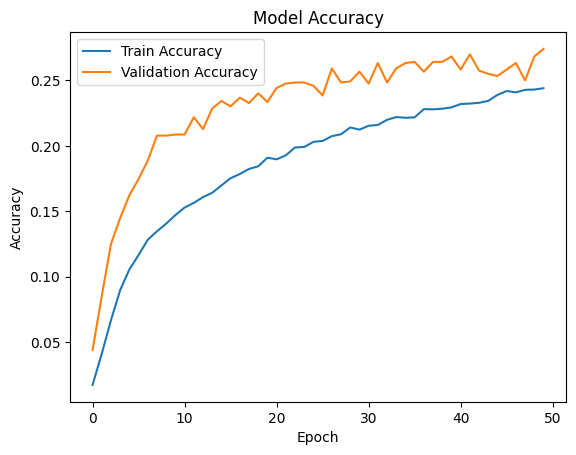

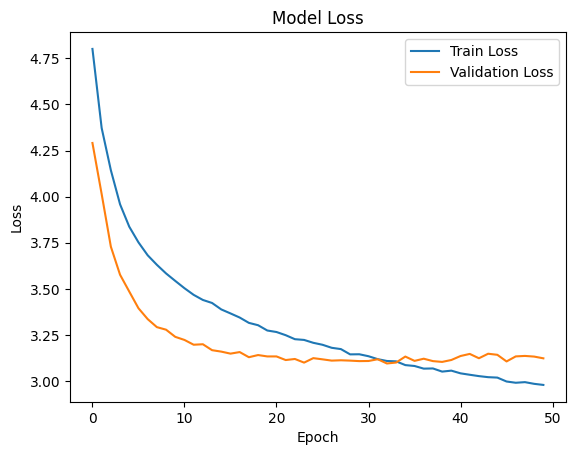

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


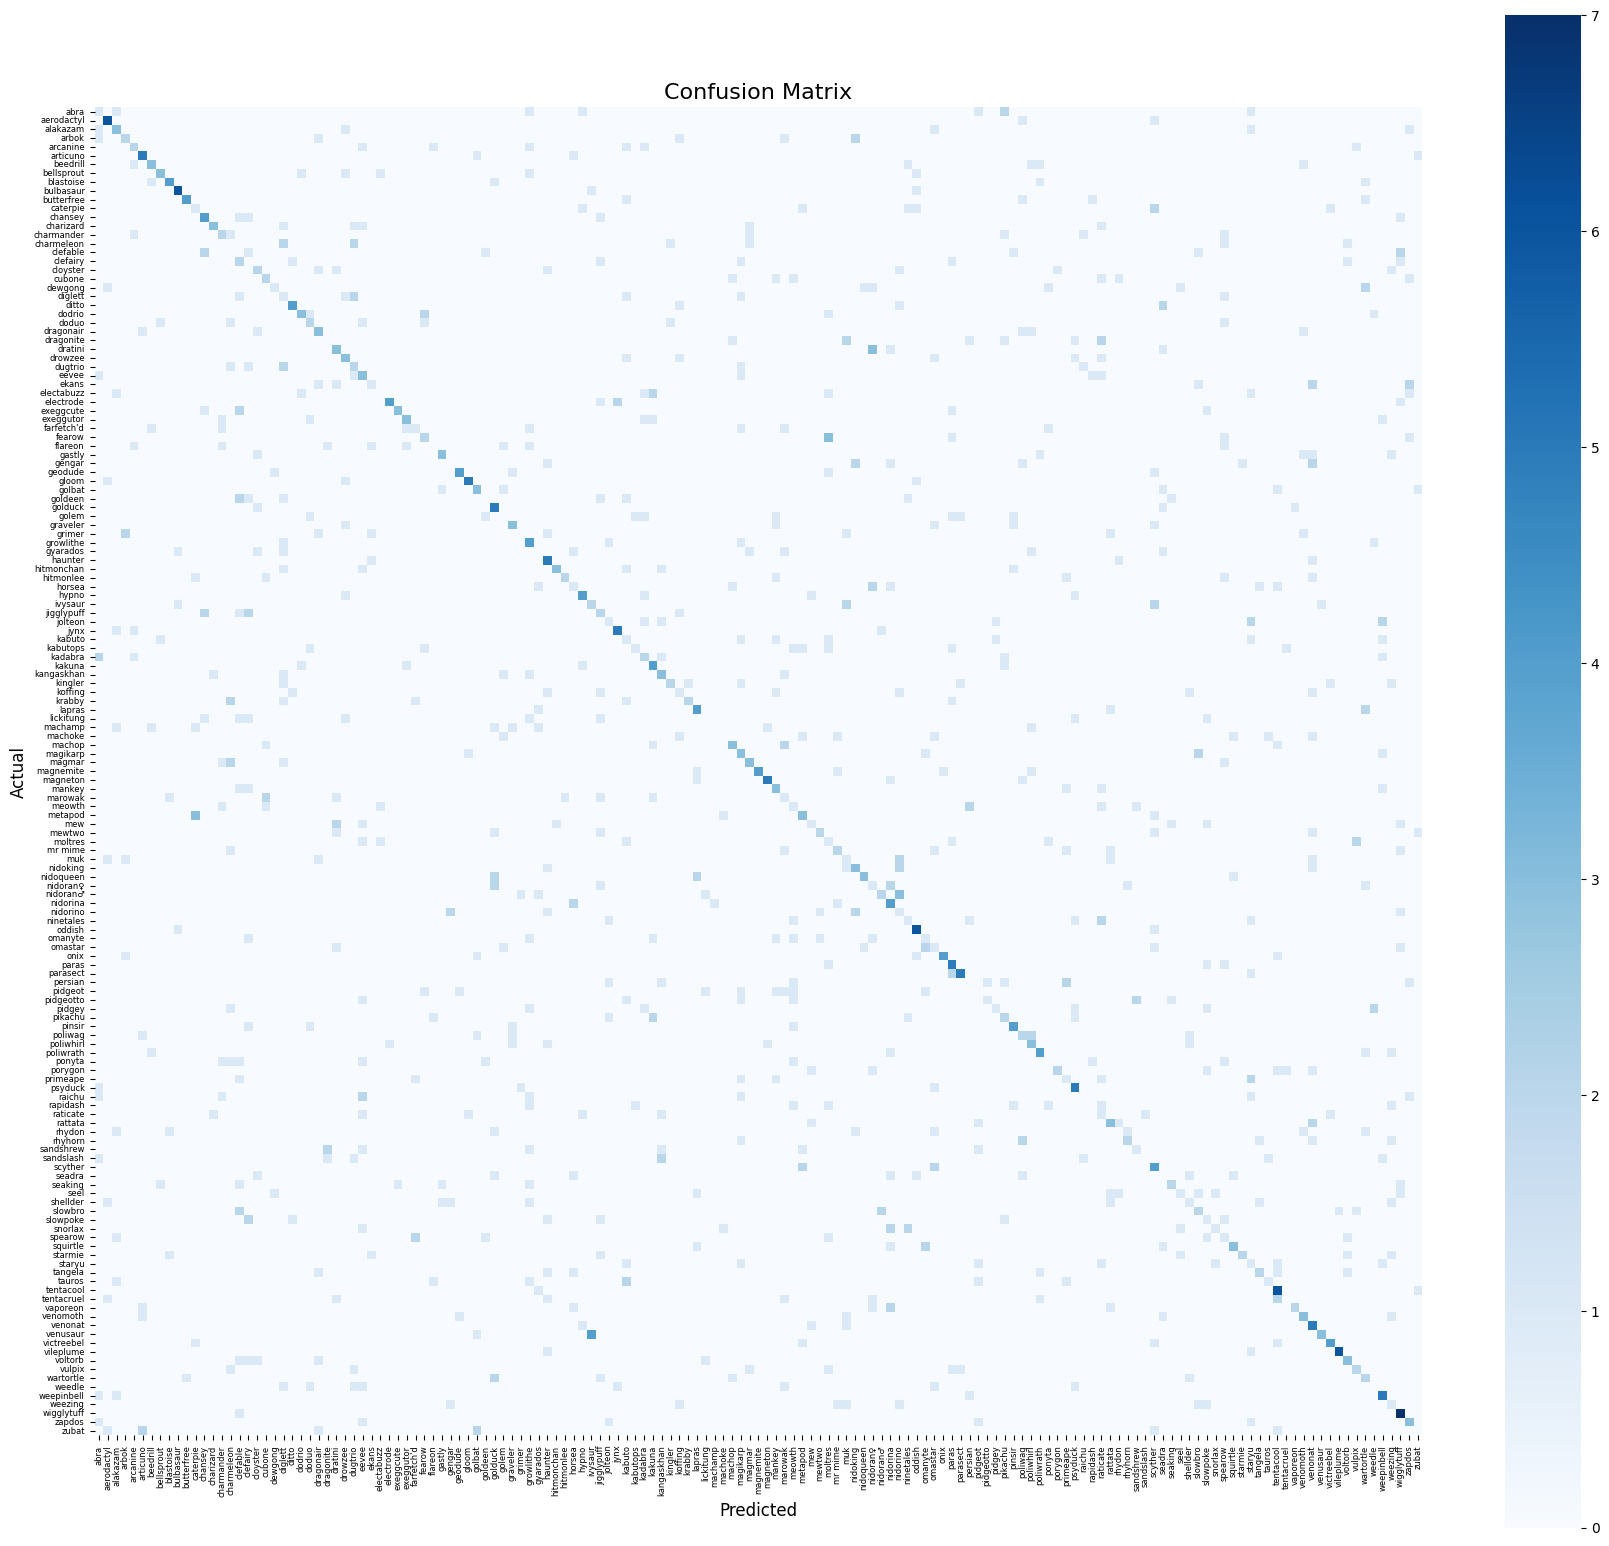

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.09      0.12      0.11         8
           1       0.50      0.75      0.60         8
           2       0.27      0.38      0.32         8
           3       0.33      0.25      0.29         8
           4       0.29      0.25      0.27         8
           5       0.45      0.62      0.53         8
           6       0.43      0.38      0.40         8
           7       0.50      0.38      0.43         8
           8       0.57      0.50      0.53         8
           9       0.67      0.75      0.71         8
          10       0.80      0.50      0.62         8
          11       0.14      0.12      0.13         8
          12       0.40      0.50      0.44         8
          13       0.60      0.38      0.46         8
          14       0.22      0.25      0.24         8
          15       0.00      0.00      0.00         8
          16       0.00      0.00      0.0

In [41]:
print("\nFinal Comparison:")
results = {}

for version in ["5aug", "10aug"]:
    model, history, acc, X_test, y_test, class_names, report, roc_auc = run_experiment(version)
    
    results[version] = {
    "accuracy": acc,
    "Validation Accuracy": max(history.history["val_accuracy"]),

    "Macro Precision": report["macro avg"]["precision"],
    "Macro Recall": report["macro avg"]["recall"],
    "Macro F1": report["macro avg"]["f1-score"],
    "Macro Support": report["macro avg"]["support"],

    "Weighted Precision": report["weighted avg"]["precision"],
    "Weighted Recall": report["weighted avg"]["recall"],
    "Weighted F1": report["weighted avg"]["f1-score"],
    "Weighted Support": report["weighted avg"]["support"],

    "ROC-AUC": roc_auc
}

    # PLOTS
    plot_training_history(history)
    plot_confusion_matrix(model, X_test, y_test, class_names)
    generate_classification_report(model, X_test, y_test)

nn_results_df = pd.DataFrame([
    {"Model": "Neural Network", "Dataset": "5aug", **results["5aug"]},
    {"Model": "Neural Network", "Dataset": "10aug", **results["10aug"]}
])

nn_results_df

nn_results_df.to_csv("nn_metrics.csv", index=False)

In [42]:
for k, v in results.items():
    print("\n", k)
    print(v)


 5aug
{'accuracy': 0.3294701874256134, 'Validation Accuracy': 0.3112582862377167, 'Macro Precision': 0.3557496722426602, 'Macro Recall': 0.3294701986754967, 'Macro F1': 0.3210500606384287, 'Macro Support': 1208.0, 'Weighted Precision': 0.3557496722426602, 'Weighted Recall': 0.3294701986754967, 'Weighted F1': 0.3210500606384287, 'Weighted Support': 1208.0, 'ROC-AUC': 0.9329891004415012}

 10aug
{'accuracy': 0.28145694732666016, 'Validation Accuracy': 0.2740066349506378, 'Macro Precision': 0.30049691410792845, 'Macro Recall': 0.2814569536423841, 'Macro F1': 0.2739992141447703, 'Macro Support': 1208.0, 'Weighted Precision': 0.30049691410792845, 'Weighted Recall': 0.2814569536423841, 'Weighted F1': 0.2739992141447703, 'Weighted Support': 1208.0, 'ROC-AUC': 0.9237224061810154}


In [43]:
print("Class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for i, count in zip(unique, counts):
    print(class_names[i], count)

Class distribution:
abra 8
aerodactyl 8
alakazam 8
arbok 8
arcanine 8
articuno 8
beedrill 8
bellsprout 8
blastoise 8
bulbasaur 8
butterfree 8
caterpie 8
chansey 8
charizard 8
charmander 8
charmeleon 8
clefable 8
clefairy 8
cloyster 8
cubone 8
dewgong 8
diglett 8
ditto 8
dodrio 8
doduo 8
dragonair 8
dragonite 8
dratini 8
drowzee 8
dugtrio 8
eevee 8
ekans 8
electabuzz 8
electrode 8
exeggcute 8
exeggutor 8
farfetch'd 8
fearow 8
flareon 8
gastly 8
gengar 8
geodude 8
gloom 8
golbat 8
goldeen 8
golduck 8
golem 8
graveler 8
grimer 8
growlithe 8
gyarados 8
haunter 8
hitmonchan 8
hitmonlee 8
horsea 8
hypno 8
ivysaur 8
jigglypuff 8
jolteon 8
jynx 8
kabuto 8
kabutops 8
kadabra 8
kakuna 8
kangaskhan 8
kingler 8
koffing 8
krabby 8
lapras 8
lickitung 8
machamp 8
machoke 8
machop 8
magikarp 8
magmar 8
magnemite 8
magneton 8
mankey 8
marowak 8
meowth 8
metapod 8
mew 8
mewtwo 8
moltres 8
mr mime 8
muk 8
nidoking 8
nidoqueen 8
nidoran♀ 8
nidoran♂ 8
nidorina 8
nidorino 8
ninetales 8
oddish 8
omanyte 8
om

The model was evaluated using accuracy, classification report, and confusion matrix. Accuracy provides an overall measure of correctness, while precision, recall, and F1-score give class-level performance insights.

A confusion matrix was used to visualize misclassifications between Pokémon classes. Additionally, reconstructed sample images confirmed that preprocessing steps preserved image quality and labels.

Training and validation curves were analyzed to assess model learning behavior and detect overfitting.

In [44]:
nn_results_df = pd.DataFrame([
    {"Model": "Neural Network", "Dataset": "5aug", **results["5aug"]},
    {"Model": "Neural Network", "Dataset": "10aug", **results["10aug"]}
])

nn_results_df

nn_results_df.to_csv("nn_metrics.csv", index=False)